<a href="https://colab.research.google.com/github/hemasree15-tech/full-stack/blob/main/DogVsCat_Classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Dog vs Cat Convolution Neural Network Classifier

### Problem statement :

In this Section we are implementing Convolution Neural Network(CNN) Classifier for Classifying dog and cat images. The Total number of images available for training is 25,000 and final testing is done on seperate 10,000 images.
#### Note:This problem statement and dataset is taken from [this](https://www.kaggle.com/c/dogs-vs-cats) Kaggle competition.

### Dependencies
* Jupyter notebook
* Tensorflow 1.10
* Python 3.6
* Matplotlib
* Seaborn
* Scikit-Learn
* Pandas
* Numpy

Install dependencies using [conda](https://conda.io/docs/)

#### Test Train Split
Image training set contain 12500 images for each category. I split those into 80% train and 20% means test Split each class images into 10,000 for train and 2,500 for test.

### Architecture
![image](resources/architecture.jpg)

In [44]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.callbacks import TensorBoard

In [45]:
from warnings import filterwarnings
filterwarnings('ignore')

Network Parameter:
* Rectifier Linear Unit
* Adam optimizer
* Sigmoid on Final output
* Binary CrossEntropy loss

In [46]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
classifier = Sequential()
classifier.add(Conv2D(32,(3,3),input_shape=(64,64,3),activation = 'relu'))
classifier.add(MaxPooling2D(pool_size=(2,2),strides=2)) #if stride not given it equal to pool filter size
classifier.add(Conv2D(32,(3,3),activation = 'relu'))
classifier.add(MaxPooling2D(pool_size=(2,2),strides=2))
classifier.add(Flatten())
classifier.add(Dense(units=128,activation='relu'))
classifier.add(Dense(units=1,activation='sigmoid'))
adam = tf.keras.optimizers.Adam(learning_rate=0.001, beta_1=0.9, beta_2=0.999, epsilon=1e-7, amsgrad=False)
classifier.compile(optimizer=adam,loss='binary_crossentropy',metrics=['accuracy'])
#tensorboard = TensorBoard(log_dir="logs/{}".format(time()))

## Data Augmentation
Using some Data Augmentation techniques for more data and Better results.
* Shearing of images
* Random zoom
* Horizontal flips

In [47]:
from google.colab import files
files.upload()  # upload your kaggle.json here

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"mvhemasree","key":"c1f60a1da579a1e63392e45a67d11b32"}'}

In [48]:
import os
print(os.listdir())  # see all folders

['.config', 'dogcat_model.h5', 'kaggle.json', 'sample_data']


In [49]:
# Download dataset from public Google Drive link
!gdown --id 1O0FkaW1SiB7faVwgtIqyVT1bFAPBOjfd

!unzip -q dogs-vs-cats.zip
import os
print(os.listdir())

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Failed to retrieve file url:

	Cannot retrieve the public link of the file. You may need to change
	the permission to 'Anyone with the link', or have had many accesses.
	Check FAQ in https://github.com/wkentaro/gdown?tab=readme-ov-file#faq.

You may still be able to access the file from the browser:

	https://drive.google.com/uc?id=1O0FkaW1SiB7faVwgtIqyVT1bFAPBOjfd

but Gdown can't. Please check connections and permissions.
unzip:  cannot find or open dogs-vs-cats.zip, dogs-vs-cats.zip.zip or dogs-vs-cats.zip.ZIP.
['.config', 'dogcat_model.h5', 'kaggle.json', 'sample_data']


In [50]:
import tensorflow as tf
import tensorflow_datasets as tfds

(train_data, test_data), info = tfds.load(
    'cats_vs_dogs',
    split=['train[:80%]', 'train[80%:]'],
    with_info=True,
    as_supervised=True
)
print("✅ Data loaded!")

✅ Data loaded!


In [51]:
def preprocess(image, label):
    image = tf.image.resize(image, (64, 64))
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

train_set = train_data.map(preprocess).batch(32).shuffle(1000)
test_set = test_data.map(preprocess).batch(32)
print("✅ Preprocessing done!")

✅ Preprocessing done!


In [52]:
history = classifier.fit(train_set,
                        epochs=10,
                        validation_data=test_set)
print("✅ Training done!")

Epoch 1/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 117s 161ms/step - accuracy: 0.6815 - loss: 0.5887 - val_accuracy: 0.7412 - val_loss: 0.5226
Epoch 2/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 108s 151ms/step - accuracy: 0.7575 - loss: 0.4966 - val_accuracy: 0.7670 - val_loss: 0.4774
Epoch 3/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 106s 149ms/step - accuracy: 0.8011 - loss: 0.4273 - val_accuracy: 0.7799 - val_loss: 0.4555
Epoch 4/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 106s 149ms/step - accuracy: 0.8337 - loss: 0.3711 - val_accuracy: 0.7893 - val_loss: 0.4431
Epoch 5/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 143s 150ms/step - accuracy: 0.8608 - loss: 0.3111 - val_accuracy: 0.7758 - val_loss: 0.4837
Epoch 6/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 108s 150ms/step - accuracy: 0.8984 - loss: 0.2422 - val_accuracy: 0.7977 - val_loss: 0.4568
Epoch 7/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 107s 152ms/step - accuracy: 0.9304 - loss: 0.1743 - val_accuracy: 0.7982 - val_loss: 0.5603
Epoch 8/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 107s 152ms/step - accuracy: 0.9587 -

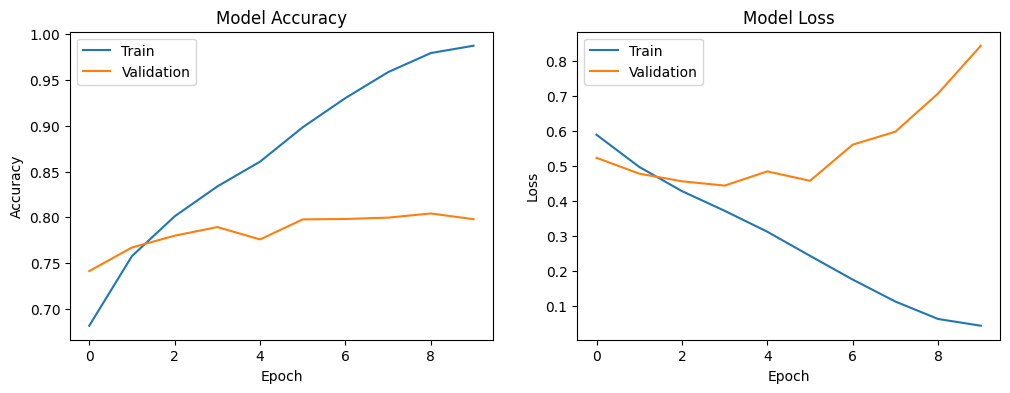

In [53]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [54]:
classifier.save('dogcat_model.h5')
print("✅ Model saved!")

✅ Model saved!


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
🐱 Cat: 69.39%


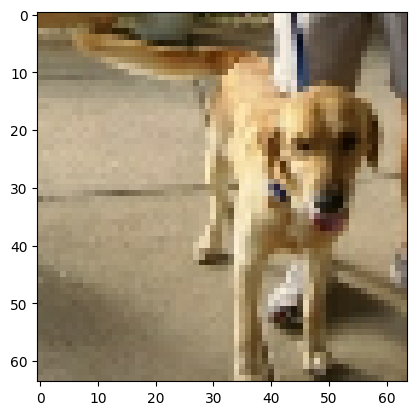

In [55]:
import numpy as np

# Take one image from test set
for images, labels in test_set.take(1):
    img = images[0]
    prediction = classifier.predict(
                 np.expand_dims(img, axis=0))
    if prediction[0][0] > 0.5:
        print("🐶 Dog: %.2f%%"
              %(prediction[0][0]*100))
    else:
        print("🐱 Cat: %.2f%%"
              %((1-prediction[0][0])*100))
    plt.imshow(img)
    plt.show()

### Prediction of Single Image

### Visualization of Layers Ouptut


### Conclusion
The Architecture and parameter used in this network are capable of producing accuracy of **97.56%** on Validation Data which is pretty good. It is possible to Achieve more accuracy on this dataset using deeper network and fine tuning of network parameters for training. You can download this trained model from resource directory and Play with it.